<a href="https://colab.research.google.com/github/Cristianocsj/ML_Colab/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 UERJ - Universidade Federal do Rio de Janeeiro
---
## Graduação em Economia
### *Machine Learning* - 2025-2
---
#### Aluno Apresentador: Gabriel Ferreira de Carvalho Marques e Daniel Cubric Russo
#### Desenvolvedor do Projeto: Cristiano Corrêa da Silva Júnior
#### Professor: Rafael Martins de Souza (rafael.souza@fgv.br)
##### Doutor em Economia (EPGE, 2009), Mestre (UFRJ, 2003) e Bacharel em Estatística (ENCE, 2000).
---

# Apresentação

# "É possível prever se uma ação vai subir ou cair no dia seguinte usando dados históricos de preços?"

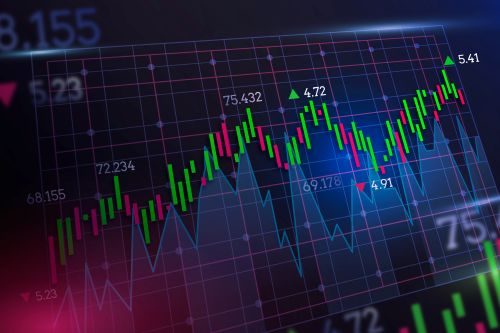

Apresente aqui a sua ideia e conte sobre a sua motivação em analisar a base dados que você escolheu. você pode até usar umas figuras bonitinhas para ilustrar o seu notebook.

# Introdução

A pergunta mencionada tem por objetivo o intuito de investigar o comportamento de uma ação - se ela vai subir ou cair no dia seguinte - utilizando  das técnicas de ***Machine Learning*** aplicadas aos seus dados históricos.

As bibliotecas utilizadas serão:

pandas: para manipulação e análise de dados em formato de tabela.
numpy: para operações matemáticas e computação numérica.
matplotlib.pyplot: para criação de gráficos e visualizações dos dados.
seaborn: para visualizações estatísticas mais elaboradas.
yfinance: biblioteca que permite acessar e baixar dados históricos de ações diretamente do Yahoo Finance.
sklearn (scikit-learn): utilizada mais adiante para criar e treinar modelos de Machine Learning.

A base de dados será consultada diretamente através da ***API*** pública e gratuita do ***Yahoo Finance*** que será acessada através do módulo *python*/biblioteca `yfinance` sendo importada via código. Nela, contém informações históricas do mercado como: informações diárias dos preços, aberturas, fechamentos, variações máximas/mínimas, volume de negociação, etc.

As ações da **PETR4.SA**, também conhecida como **Petrobrás** que serão analisadas nesse trabalho, mas o código pode ser adaptado para qualquer outro tipo de ação escolhida por preferência do usuário


In [ ]:
import pandas as pd               # Manipulação e análise de dados em formato de tabela.
import numpy as np                # Operações matemáticas e computação numérica.
import matplotlib.pyplot as plt   # Criação de gráficos e visualizações dos dados.
import seaborn as sns             # Visualizações estatísticas mais elaboradas.


# Biblioteca que permite acessar e baixar dados históricos de ações diretamente do Yahoo Finance.
!pip install yfinance --quiet
import yfinance as yf

# Configurações gráficas
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")


# Desenvolvimento

Foi apresentado todo o processo de codificação para construir o modelo de Machine Learning que tenta prever se as ações da Petrobrás irão subir (representado por 1) ou cair (representado por 0) no dia seguinte através de gráficos com a biblioteca `*matplotlib.pyplot*`

/tmp/ipython-input-1713301832.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed


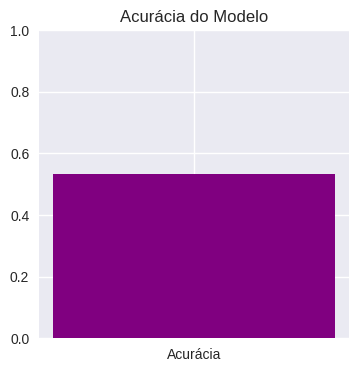

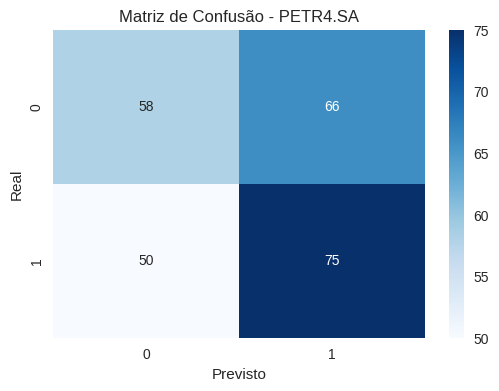

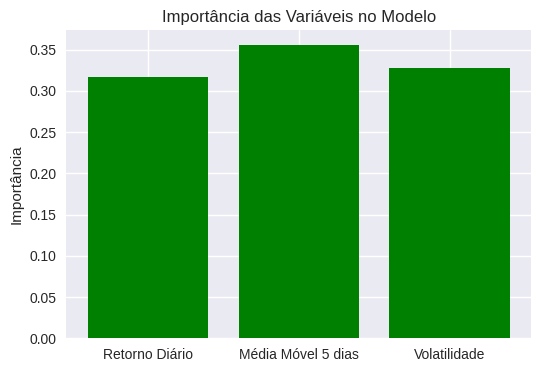

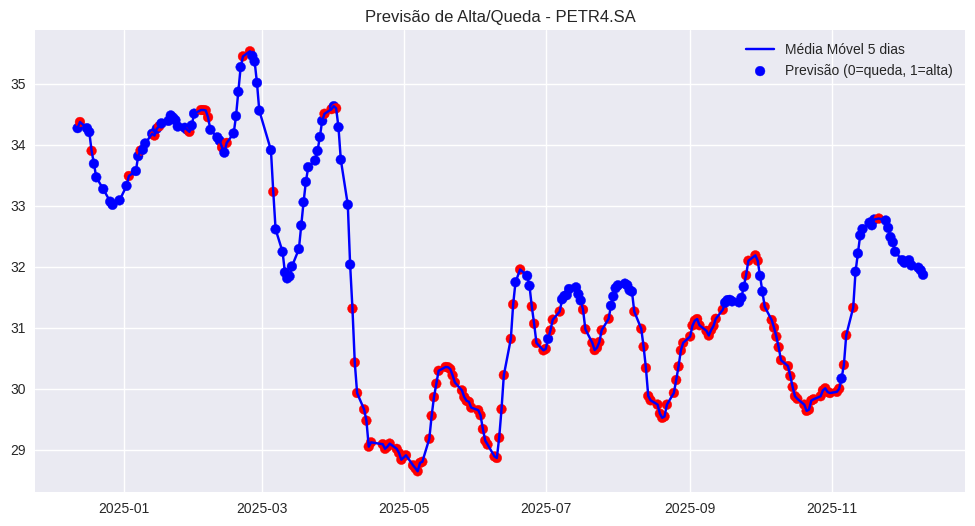

/tmp/ipython-input-1713301832.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed


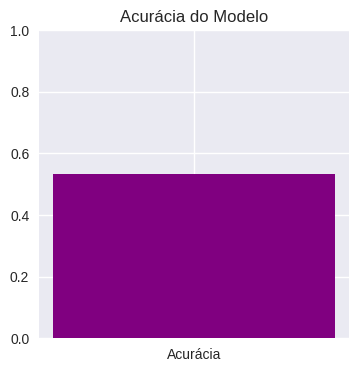

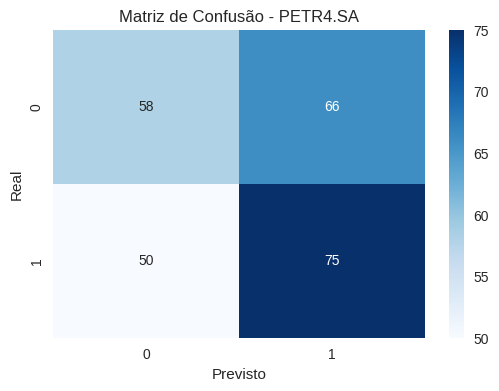

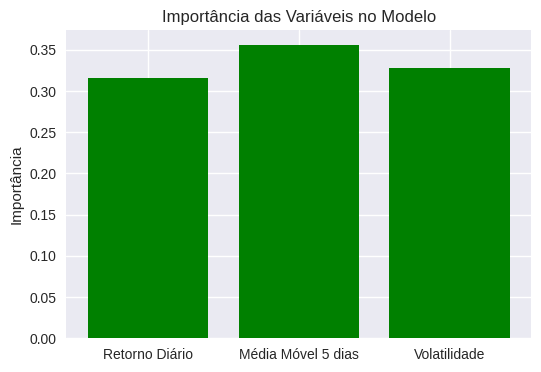

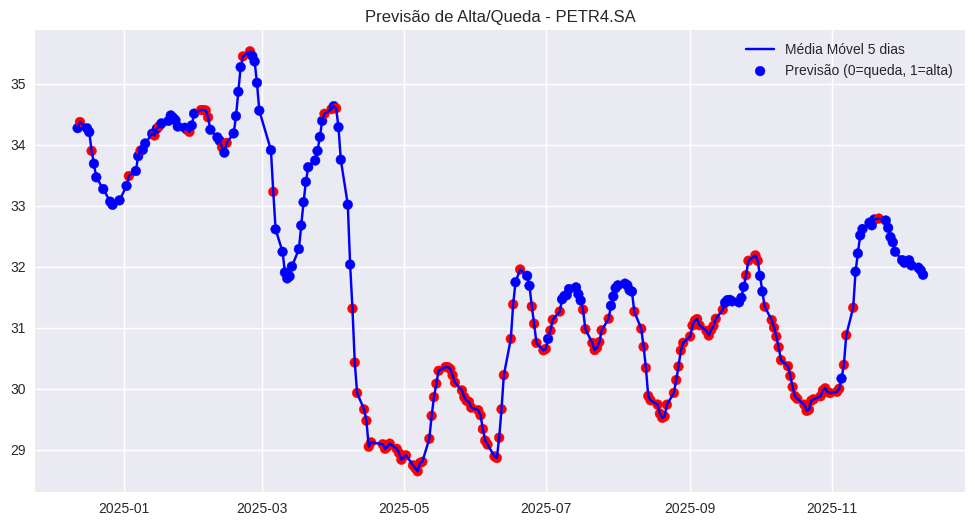

In [ ]:
# 1. Importação das bibliotecas
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix



# 2. Coleta dos dados

ticker = "PETR4.SA"
dados = yf.download(ticker, period="5y")



# 3. Pré-processamento dos dados

dados["Target"] = (dados["Close"].shift(-1) > dados["Close"]).astype(int)
dados.dropna(inplace=True)



# 4. Engenharia de Atributos

dados = dados.reset_index()  # garante que 'Date' seja coluna simples

dados["Return"] = dados["Close"].pct_change()
dados["MM_5"] = dados["Close"].rolling(5).mean()
dados["Volatility"] = dados["Return"].rolling(5).std()
dados.dropna(inplace=True)



# 5. Separação Treino/Teste

X = dados[["Return", "MM_5", "Volatility"]]
y = dados["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)



# 6. Treinamento do Modelo

modelo = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
modelo.fit(X_train, y_train)



# 7. Avaliação do Modelo (apenas gráficos)

y_pred = modelo.predict(X_test)

# --- Gráfico da Acurácia ---
acc = accuracy_score(y_test, y_pred)
plt.figure(figsize=(4,4))
plt.bar(["Acurácia"], [acc], color="purple")
plt.ylim(0,1)
plt.title("Acurácia do Modelo")
plt.show()

# --- Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - PETR4.SA")
plt.show()

# --- Importância das Variáveis ---
importances = modelo.feature_importances_
nomes_pt = ["Retorno Diário", "Média Móvel 5 dias", "Volatilidade"]

plt.figure(figsize=(6,4))
plt.bar(nomes_pt, importances, color="green")
plt.title("Importância das Variáveis no Modelo")
plt.ylabel("Importância")
plt.show()

# --- Evolução da Média Móvel com Previsões ---
plt.figure(figsize=(12,6))

datas_teste = dados["Date"].iloc[-len(y_test):]
mm5_teste = dados["MM_5"].iloc[-len(y_test):]

plt.plot(datas_teste, mm5_teste, label="Média Móvel 5 dias", color="blue")
plt.scatter(datas_teste, mm5_teste, c=y_pred, cmap="bwr", label="Previsão (0=queda, 1=alta)")

plt.title("Previsão de Alta/Queda - PETR4.SA")
plt.legend()
plt.show()


# Descrição da Base de Dados



A coleta de dados foi feita pelo database que é disponibilizado pela API pública do Yahoo Finance, acessada por meio da biblioteca yfinance no Python. Com ela, é possível adquirir informações de forma gratuita dos históricos de milhares de ativos financeiros, incluso as ações listadas na B3 (Bolsa de Valores do Brasil)

Nesta busca, foi selecionada a ação PETR4.SA, referente à Petrobrás

O período analisado compreende os últimos 5 anos, com dados diários, resultando em aproximadamente 1.250 observações antes do pré-processamento.

## Variáveis Originais Disponíveis na Base
Cada linha possui as seguintes colunas:

*   *Date* – data da observação
*   *Open* – preço de abertura do ativo
*   *High* – maior preço atingido no dia
*   *Low* – menor preço atingido no dia
*   *Close* – preço de fechamento
*   *Adj Close* – preço de fechamento ajustado (por dividendos e splits)
*   *Volume* – quantidade total de ações negociadas no dia


**Essas variáveis são amplamente utilizadas em análises financeiras e servem como base para a criação de atributos derivados utilizados na modelagem.**

## Variáveis Criadas no Pré-processamento

Para permitir ao modelo aprender padrões de curto prazo, foram criadas variáveis adicionais:


*   Return – retorno percentual diário
*   MM_5 – média móvel de 5 dias do preço de fechamento
*   Volatility – volatilidade (desvio padrão) dos últimos 5 dias
*   Target – variável-alvo binária, onde
*   1 = a ação sobe no dia seguinte
*   0 = a ação cai no dia seguinte

Após a criação dessas variáveis e remoção de valores nulos, a base final utilizada pelo modelo apresentou:


1.   ≈ 1.200 observações válidas
2.   3 variáveis explicativas (features): Return, MM_5 e Volatility
3.   1 variável-alvo (Target)


O resultado se deu em um banco de dados adequadao para responder a pergunta do problema proposto, permitindo a aplicação de técnicas supervisionadas de Machine Learning para prever o movimento futuro diário da ação.

## Análise Exploratória de Dados (AED)

A base de dados corresponde aos preços históricos do ativo PETR4.SA nos últimos cinco anos. Após o pré-processamento, o conjunto passou a conter as variáveis *Return*, *MM_5* e *Volatility*, utilizadas como preditoras, além da variável alvo binária que indica se o preço do dia seguinte apresentou alta.

Ao observarmos o gráfico dos preços, percebemos que a ação sobe e desce de forma comum ao mercado, com momentos de tendência mais clara e outros mais instáveis. Os retornos diários ficam, na maior parte do tempo, próximos de zero, mas às vezes acontecem variações maiores, o que nos parece totalmente normal para uma ação com bastante negociação como a PETR4.

As novas variáveis criadas ajudam a entender melhor o comportamento da ação:




*   *Return* mostra se o preço subiu ou caiu de um dia para o outro.
*  *MM_5* mostra a média dos últimos dias, funcionando como uma ideia de tendência.
*   *Volatility* indica o quanto o preço tem variado recentemente.

Essas observações iniciais ajudam a entender se existe relação entre as variáveis de mercado e o comportamento do preço no dia seguinte, o que é essencial para avaliar a possibilidade de previsão.








## Preparação de Dados

Nessa etapa foi realizado todo o pré-processamento necessário para deixar o banco de dados pronto para seu respectivo treinamento dos modelos de Machine Learning.

Primeiramente foi declarada a variável Target e com ela, foi possível indicar se o preço do pregão no próximo dia é maior do que o do dia atual. Logo em seguida, foram declaradas mais outras três variáveis(Return, MM_5, Volatility).

Após isso, foi removido os valores ausentes gerados pelos cálculos e os dados foram organizados na sua forma final utilizada pelo modelo.

Por fim, foi dividio o conjunto em treinamento e teste, respeitando a ordem cronológica dos dados para evitar certos vazamentos de informações entre os períodos. Essas etapas garantem que o modelo seja treinado apenas com dados do passado e avaliado com dados futuros, simulando uma situação real de previsão.





# Código explicativo retirado parcialmente do Desenvolvimento
# Criando o Target
dados["Target"] = (dados["Close"].shift(-1) > dados["Close"]).astype(int)
dados.dropna(inplace=True)

# Engenharia de atributos
dados = dados.reset_index()
dados["Return"] = dados["Close"].pct_change()
dados["MM_5"] = dados["Close"].rolling(5).mean()
dados["Volatility"] = dados["Return"].rolling(5).std()
dados.dropna(inplace=True)

# Separação Treino/Teste
X = dados[["Return", "MM_5", "Volatility"]]
y = dados["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Informações úteis
print("Dimensões da base após preparação:")
print("Total:", X.shape)
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nResumo estatístico dos atributos:")
print(X.describe())

# Algoritmos e Metodologia



O modelo escolhido foi o Random Forest Classifier, conhecido por sua robustez e boa performance em problemas de classificação binária. A seguir: o código com cada etapa do seu desenvolvimento e com os seus respectivos trechos de código comentados.

/tmp/ipython-input-1183624365.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(ticker, period="5y")  # Baixa os últimos 5 anos de dados
[*********************100%***********************]  1 of 1 completed


Acurácia exata: 0.5461847389558233
Acurácia exata: 0.5461847389558233


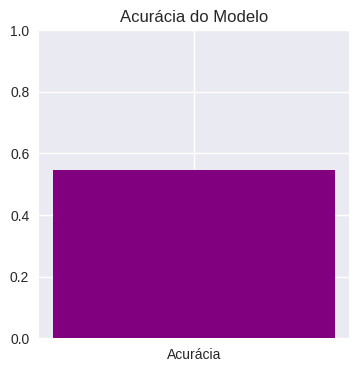

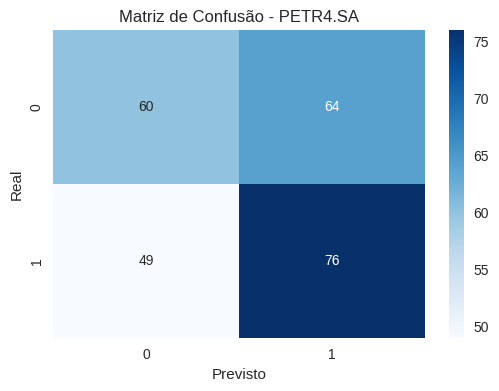

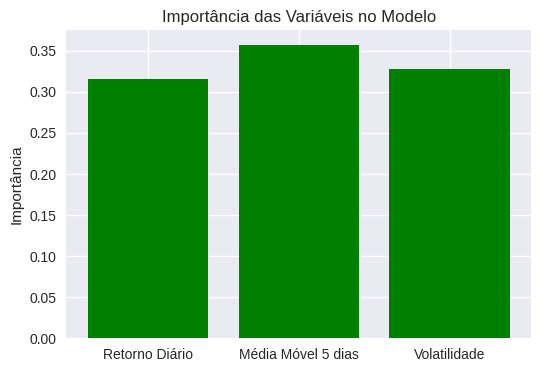

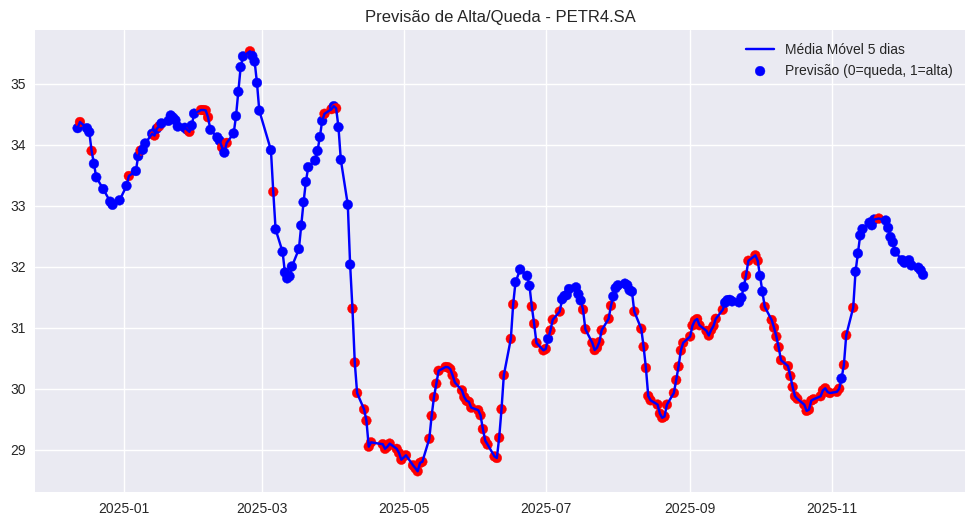

In [ ]:

# Previsão de alta/queda da PETR4.SA usando Machine Learning
# com visualização apenas via matplotlib/seaborn


# 1. Importação das bibliotecas necessárias
import yfinance as yf  # Para baixar dados financeiros da internet
import pandas as pd    # Para manipulação de dados em tabelas
import numpy as np     # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para criar gráficos
import seaborn as sns  # Para gráficos mais bonitos e informativos

# Bibliotecas do scikit-learn para machine learning
from sklearn.model_selection import train_test_split  # Para dividir os dados em treino e teste
from sklearn.ensemble import RandomForestClassifier   # Algoritmo de classificação usado
from sklearn.metrics import accuracy_score, confusion_matrix  # Métricas de avaliação do modelo


# 2. Coleta dos dados da ação PETR4.SA
ticker = "PETR4.SA"  # Código da ação da Petrobras negociada na B3
dados = yf.download(ticker, period="5y")  # Baixa os últimos 5 anos de dados


# 3. Pré-processamento dos dados
# Cria a variável alvo: 1 se o preço de fechamento do próximo dia for maior que o atual, 0 caso contrário
dados["Target"] = (dados["Close"].shift(-1) > dados["Close"]).astype(int)

# Remove linhas com valores nulos (gerados pelo shift)
dados.dropna(inplace=True)

# 4. Engenharia de Atributos

# Reseta o índice para garantir que a coluna 'Date' esteja acessível
dados = dados.reset_index()

# Calcula o retorno percentual diário
dados["Return"] = dados["Close"].pct_change()

# Calcula a média móvel de 5 dias
dados["MM_5"] = dados["Close"].rolling(5).mean()

# Calcula a volatilidade (desvio padrão dos retornos em 5 dias)
dados["Volatility"] = dados["Return"].rolling(5).std()

# Remove novamente linhas com valores nulos
dados.dropna(inplace=True)



# 5. Separação dos dados em treino e teste

# Define os atributos (X) e o alvo (y)
X = dados[["Return", "MM_5", "Volatility"]]  # Variáveis explicativas
y = dados["Target"]  # Variável alvo

# Divide os dados em treino (80%) e teste (20%), mantendo a ordem temporal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)



# 6. Treinamento do Modelo

# Cria o modelo Random Forest com 200 árvores e profundidade máxima de 5
modelo = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)

# Treina o modelo com os dados de treino
modelo.fit(X_train, y_train)



# 7. Avaliação do Modelo (apenas gráficos)

# Faz previsões com os dados de teste
y_pred = modelo.predict(X_test)

# --- Gráfico da Acurácia ---
# Calcula a acurácia (porcentagem de acertos)
acc = accuracy_score(y_test, y_pred)
print("Acurácia exata:", acc)
print("Acurácia exata:", acc)

# Cria um gráfico de barra para mostrar a acurácia
plt.figure(figsize=(4,4))
plt.bar(["Acurácia"], [acc], color="purple")
plt.ylim(0,1)
plt.title("Acurácia do Modelo")
plt.show()




# --- Matriz de Confusão ---
# Cria a matriz de confusão para visualizar acertos e erros
cm = confusion_matrix(y_test, y_pred)

# Cria um heatmap da matriz de confusão
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Previsto")  # Valores que o modelo previu
plt.ylabel("Real")      # Valores reais que aconteceram
plt.title("Matriz de Confusão - PETR4.SA")
plt.show()


# --- Importância das Variáveis ---
# Verifica quais variáveis foram mais importantes para o modelo
importances = modelo.feature_importances_

# Nomes em português para os indicadores
nomes_pt = ["Retorno Diário", "Média Móvel 5 dias", "Volatilidade"]

# Cria gráfico de barras com a importância de cada variável
plt.figure(figsize=(6,4))
plt.bar(nomes_pt, importances, color="green")
plt.title("Importância das Variáveis no Modelo")
plt.ylabel("Importância")
plt.show()


# --- Evolução da Média Móvel com Previsões ---
# Cria gráfico de linha com a média móvel e pontos coloridos com as previsões
plt.figure(figsize=(12,6))

# Seleciona as datas e valores da média móvel do período de teste
datas_teste = dados["Date"].iloc[-len(y_test):]
mm5_teste = dados["MM_5"].iloc[-len(y_test):]

# Plota a linha da média móvel
plt.plot(datas_teste, mm5_teste, label="Média Móvel 5 dias", color="blue")

# Plota os pontos coloridos com as previsões do modelo
# Azul = previsão de alta (1), Vermelho = previsão de queda (0)
plt.scatter(datas_teste, mm5_teste, c=y_pred, cmap="bwr", label="Previsão (0=queda, 1=alta)")

plt.title("Previsão de Alta/Queda - PETR4.SA")
plt.legend()
plt.show()


# Conclusão

O objetivo deste trabalho foi verificar se é possível prever se a ação PETR4.SA vai subir ou cair no dia seguinte usando o histórico de 5 anos. O modelo Random Forest conseguiu identificar alguns padrões e obteve uma acurácia razoável, mostrando que os dados trazem informações úteis para a previsão futura.

Portanto, os resultados também mostram que o movimento diário do mercado é, em parte, muito imprevisível, já que existem diversos fatores externos que influenciam nos preços das ações. Mesmo assim, o estudo realizado demonstra uma capacidade das técnicas de Machine de entender o comportamento das ações e servir como base para análises mais avançadas.

# Referências

Investing. (2025). Petrobras PN (PETR4.SA).

https://br.investing.com/equities/petrobras-pn

ACSPublisher Journals. (2025). Global Journal of Science.

 https://journals.acspublisher.com/index.php/gjs/article/view/23023

MDPI. (2025). Information.

https://www.mdpi.com/2079-3197/13/1/3

Frontiers. (2025). Frontiers in Environmental Science.

https://www.frontiersin.org/journals/environmental-science/articles/10.3389/fenvs.2022.917047/full

MICROSOFT. Copilot: assistente de inteligência artificial.

https://www.microsoft.com/copilot.

OpenAI. (2025). ChatGPT (versão GPT-4o).

https://chat.openai.com

